# Triplet lifetime monitor

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob
import datetime
import math
import uproot
import ROOT
from scipy.optimize import curve_fit
from scipy.optimize import least_squares
import scipy.integrate as intg 
from scipy.stats import norm
from numpy.random import normal
import sipm.recon.WaveformAnalyzer as wfa
import sipm.recon.WaveformDataset as wfd
import sipm.util.functions as func
from datetime import datetime
from scipy.fft import fft, ifft

plt.style.use('darkside')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

## View raw waveforms to find out exact trigger position

trigger_position: 700
trigger_position: 700
trigger_position: 700
trigger_position: 700
/scratch/gpfs/GALBIATI/data/sipm//xart_long_wf/2025-02-14/2025-02-14_volt_98_light_scintillation_source_na22_cond_monitor/0/wave1.dat
10 events
/scratch/gpfs/GALBIATI/data/sipm//xart_long_wf/2025-02-14/2025-02-14_volt_98_light_scintillation_source_na22_cond_monitor/0/wave2.dat
10 events
/scratch/gpfs/GALBIATI/data/sipm//xart_long_wf/2025-02-14/2025-02-14_volt_98_light_scintillation_source_na22_cond_monitor/0/wave4.dat
10 events
/scratch/gpfs/GALBIATI/data/sipm//xart_long_wf/2025-02-14/2025-02-14_volt_98_light_scintillation_source_na22_cond_monitor/0/wave7.dat
10 events


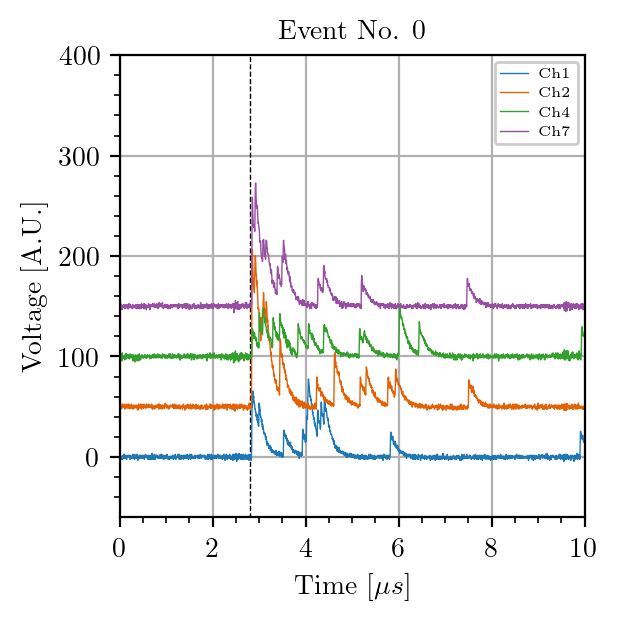

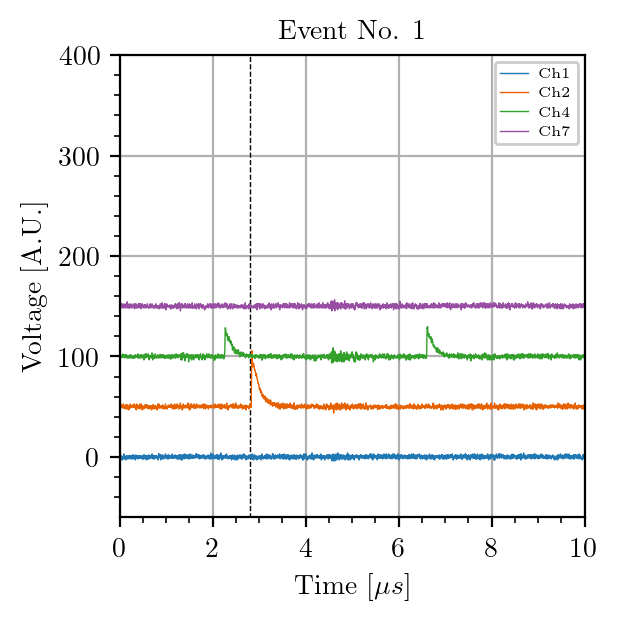

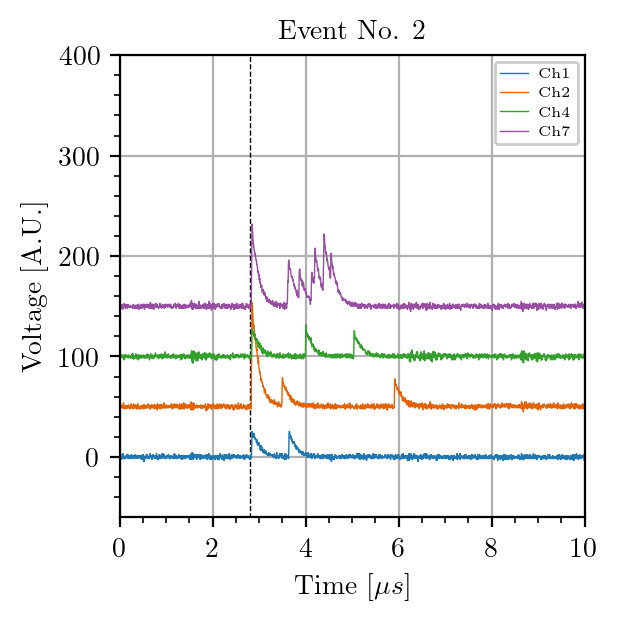

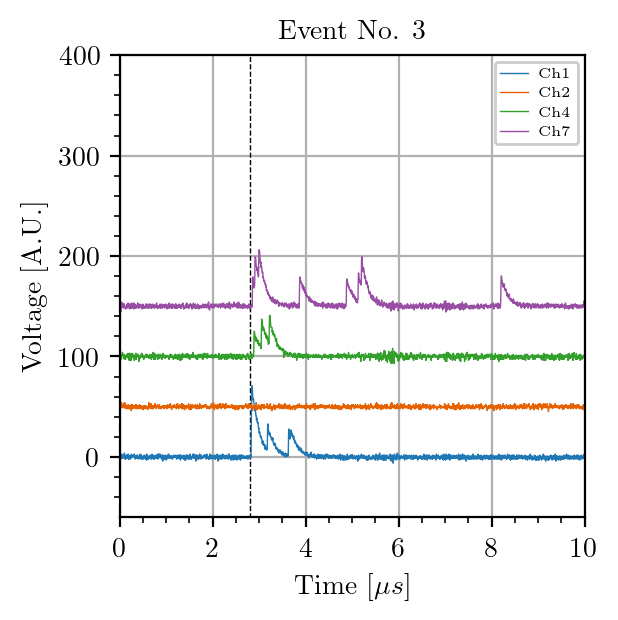

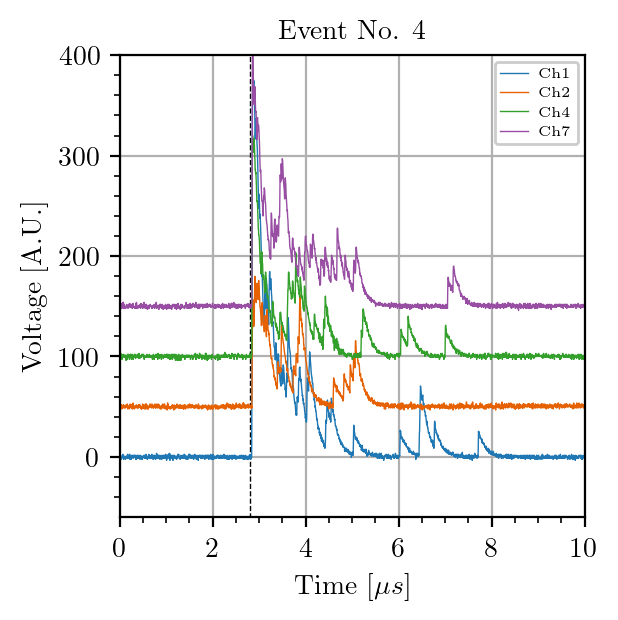

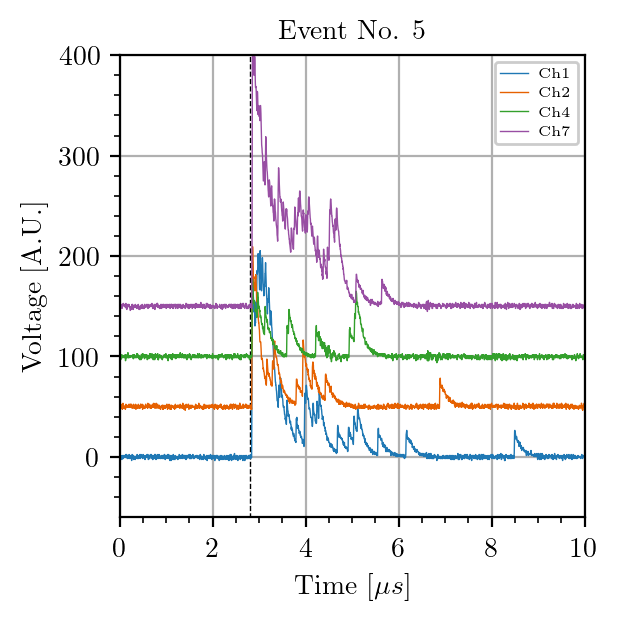

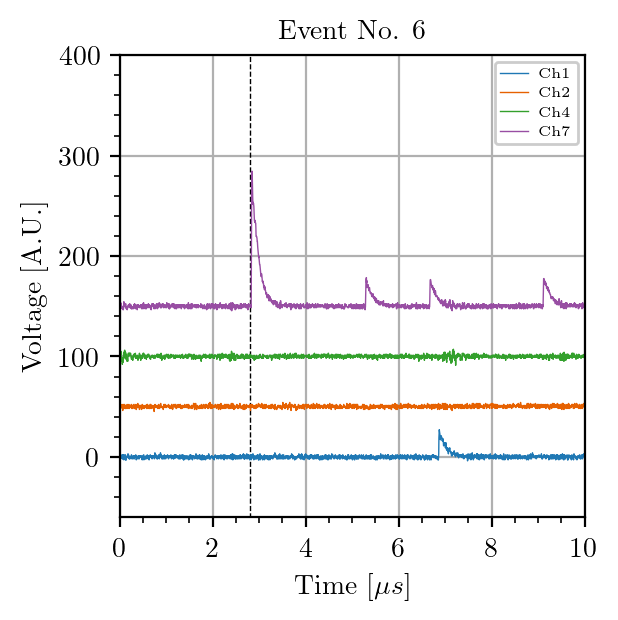

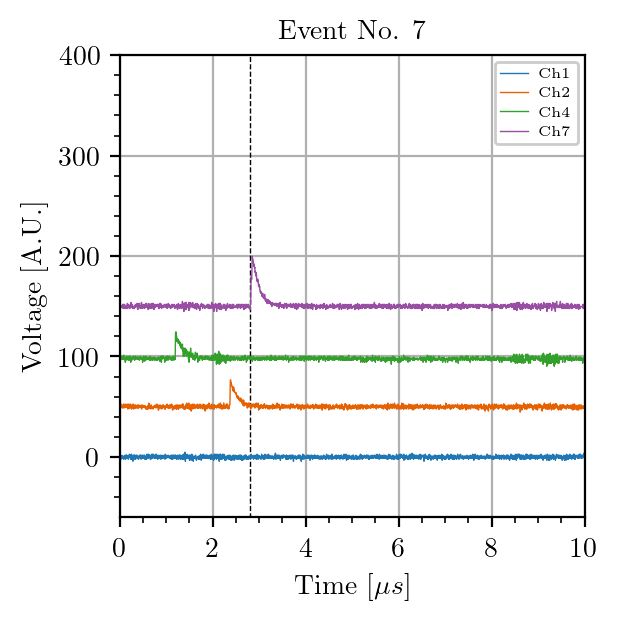

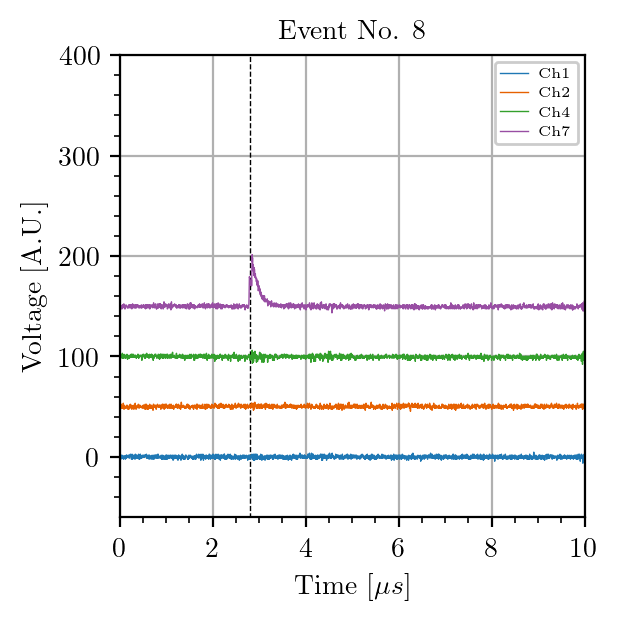

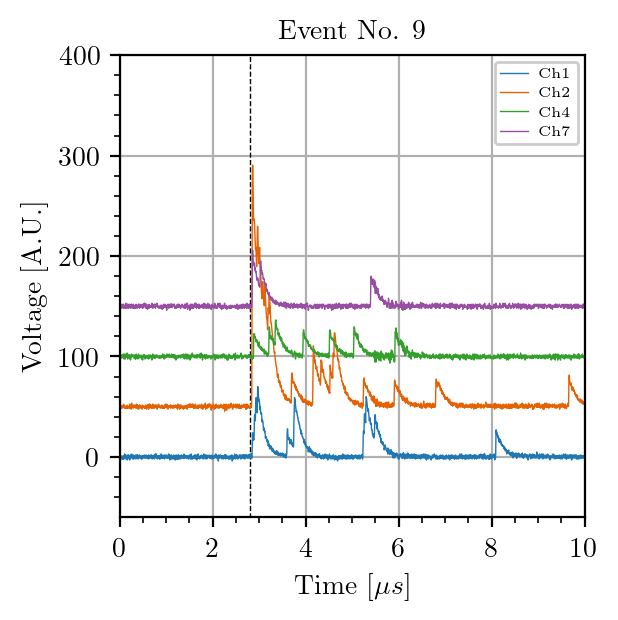

In [32]:
evid = np.arange(0, 10)
channels = [1,2,4,7]
trig = 700
dset = wfd.WaveformDataset(
    path='/scratch/gpfs/GALBIATI/data/sipm/xart_long_wf/2025-02-14/2025-02-14_volt_98_light_scintillation_source_na22_cond_monitor/0/', 
    pol=-1, 
    channels=channels,
    trig=trig)
wfs = []
for ch in channels:
    wfs.append(dset.ch[ch].get_waveforms(ev=evid, ar_filter=False)[0])
# wfs dimensions: (channels, events, samples)
wfs = np.transpose(wfs, (1,0,2)) # (events, channels, samples)
for i,wf in enumerate(wfs):
    plt.figure(i, figsize=(3, 3))
    plt.plot([trig*4e-3]*2,[-600, 400], 'k--', lw=0.5) # show trigger position
    for j,ch in enumerate(channels):
        plt.plot(dset.ch[ch].time, wf[j]+j*50, label=f'Ch{ch}', linewidth=0.5)
    plt.legend(loc='upper right', fontsize=5)
    plt.xlabel(r'Time [$\mu s$]')
    plt.ylabel(r'Voltage [A.U.]')
    plt.minorticks_on()
    plt.grid()
    plt.xlim(0, 10)
    plt.ylim(-60, 400)
    plt.title(f'Event No. {evid[i]}')

## Define functions

In [3]:
def load_data(file_list, channel_list, volt):
    df_ch = {}
    dt = 0
    for ch in channel_list:
        df_ch[ch] = []
        for f in file_list:
            df = pd.read_hdf(f, key=f'{volt}/{ch}')
            df_ch[ch].append(df)
            if ch==-1:
                dt = datetime(*np.array(df['start_datetime'][:6]).astype(int))
            df = None
        df_ch[ch] = pd.concat(df_ch[ch]).sort_index()
        if ch!=-1:
            df_ch[ch].rename(columns=lambda x: x+f'_{ch}',inplace=True)            
    df_ch = pd.concat(list(df_ch.values()),axis=1)
    return df_ch, dt

def get_bsl_filt(df_data,channels,rms_thre_ch):
    df_bsl_filt = {}
    for ch in channels:
        df_bsl_filt[f'bsl_filt_{ch}'] = df_data[f'baseline_rms_{ch}']<rms_thre_ch[ch]
        # print(df_bsl_filt[f'bsl_filt_{ch}'].sum())
    df_bsl_filt = pd.DataFrame(df_bsl_filt)
    df_bsl_filt['bsl_filt'] =  df_bsl_filt[[f'bsl_filt_{ch}' for ch in channels]].all(axis=1)
    return df_bsl_filt

def get_bsl_rms_hist(df_data,channels,bins,range):
    hist_ch = {}
    for ch in channels:
        hist_ch[ch] = np.histogram(df_data[f'baseline_rms_{ch}'], bins=bins, range=range)
    return hist_ch

def get_bsl_mean_hist(df_data,channels,bsl_filt,bins,range):
    hist_ch = {}
    for ch in channels:
        if bsl_filt:
            hist_ch[ch] = np.histogram(df_data.loc[df_data[f'bsl_filt_{ch}'],f'baseline_mean_{ch}'], bins=bins, range=range)
        else:
            hist_ch[ch] = np.histogram(df_data[f'baseline_mean_{ch}'], bins=bins, range=range)
    return hist_ch

## Organize file paths

In [6]:
path = "/scratch/gpfs/as111/results/"
files = glob(f'{path}2025-02-14/*cond_monitor*.h5')
print(len(files),files)

16 ['/scratch/gpfs/as111/results/2025-02-14/2025-02-14_volt_98_light_scintillation_cond_monitor_source_na22_run8_scintillation_pulse_liq8.h5', '/scratch/gpfs/as111/results/2025-02-14/2025-02-14_volt_98_light_scintillation_cond_monitor_source_na22_run11_scintillation_pulse_liq8.h5', '/scratch/gpfs/as111/results/2025-02-14/2025-02-14_volt_98_light_scintillation_cond_monitor_source_na22_run7_scintillation_pulse_liq8.h5', '/scratch/gpfs/as111/results/2025-02-14/2025-02-14_volt_98_light_scintillation_cond_monitor_source_na22_run5_scintillation_pulse_liq8.h5', '/scratch/gpfs/as111/results/2025-02-14/2025-02-14_volt_98_light_scintillation_cond_monitor_source_na22_run12_scintillation_pulse_liq8.h5', '/scratch/gpfs/as111/results/2025-02-14/2025-02-14_volt_98_light_scintillation_cond_monitor_source_na22_run14_scintillation_pulse_liq8.h5', '/scratch/gpfs/as111/results/2025-02-14/2025-02-14_volt_98_light_scintillation_cond_monitor_source_na22_run1_scintillation_pulse_liq8.h5', '/scratch/gpfs/as111

## Read data

In [11]:
data = {}
channels = [1,2,4,7]
volt = 98
date_time = []
for f in files:
	df, dt = load_data([f], [-1]+channels, volt)
	data[dt] = df
	print(f'{df.shape[0]} events {dt}')
	date_time.append(dt)
print('columns: ', list(data[date_time[0]].columns))
date_time.sort()

50397 events 2025-02-16 13:04:29
50473 events 2025-02-17 07:12:03
50345 events 2025-02-16 07:01:55
50215 events 2025-02-15 18:56:45
50209 events 2025-02-17 13:14:34
50241 events 2025-02-18 01:19:38
50220 events 2025-02-14 18:46:14
50349 events 2025-02-15 12:54:08
50157 events 2025-02-17 19:17:07
50094 events 2025-02-17 01:09:31
50181 events 2025-02-15 06:51:32
50361 events 2025-02-15 00:48:52
50424 events 2025-02-18 07:22:10
50362 events 2025-02-16 00:59:20
50137 events 2025-02-16 19:07:00
50309 events 2025-02-14 12:43:31
columns:  ['start_datetime', 'end_datetime', 'duration_seconds', 'total_pe', 'fprompt_0p30us_1247', 'baseline_mean_1', 'baseline_rms_1', 'integral_0p30us_1', 'integral_7p00us_1', 'amplitude_1', 'peakpos_1', 'baseline_mean_2', 'baseline_rms_2', 'integral_0p30us_2', 'integral_7p00us_2', 'amplitude_2', 'peakpos_2', 'baseline_mean_4', 'baseline_rms_4', 'integral_0p30us_4', 'integral_7p00us_4', 'amplitude_4', 'peakpos_4', 'baseline_mean_7', 'baseline_rms_7', 'integral_0p30

## Pre-trigger RMS cut

In [12]:
rms_threshold = {1:2.0, 2:2.0, 4:2.0, 7:2.0}
for dt in date_time:
    df_bsl_filt = get_bsl_filt(data[dt],[1,2,4,7],rms_threshold)
    data[dt][df_bsl_filt.columns] = df_bsl_filt
    df_bsl_filt = None

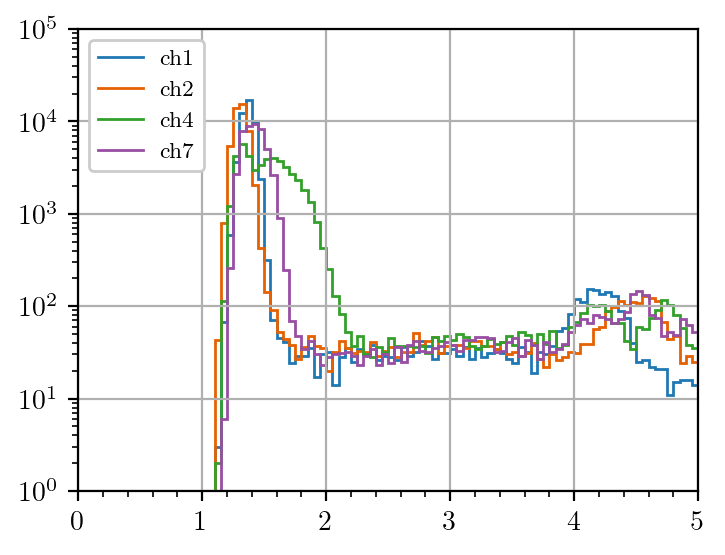

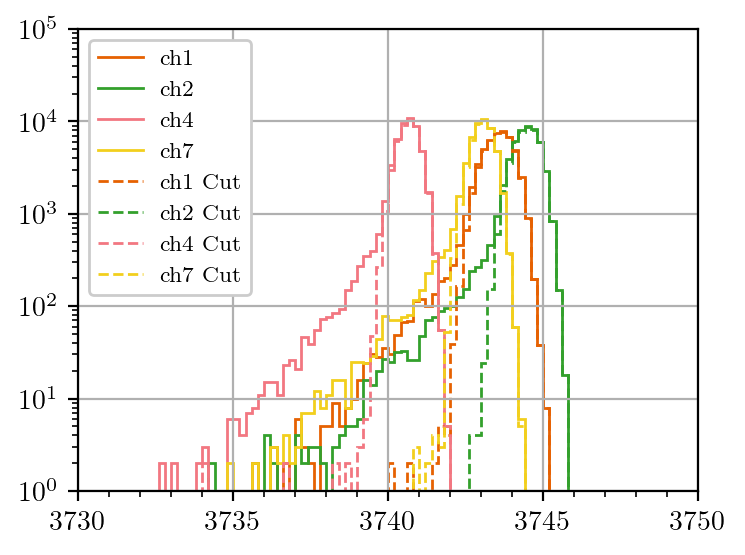

In [16]:
dt = date_time[0]

plt.figure(0)
hists = get_bsl_rms_hist(data[dt],[1,2,4,7],100,(0,5))
for ch,hist in hists.items():
	plt.stairs(*(hist),label=f'ch{ch}')
plt.legend()
plt.yscale('log')
plt.grid()
plt.minorticks_on()

plt.figure(1)
hists_nc = get_bsl_mean_hist(data[dt],[1,2,4,7],False,100,(3730,3750))
hists_ac = get_bsl_mean_hist(data[dt],[1,2,4,7],True,100,(3730,3750))
for ch,hist in hists_nc.items():
	plt.stairs(*(hist),color=f'C{ch}',label=f'ch{ch} ')
for ch,hist in hists_ac.items():
	plt.stairs(*(hist),color=f'C{ch}',label=f'ch{ch} Cut',ls='--')
plt.legend()
plt.yscale('log')
plt.grid()
plt.minorticks_on()

## Npe - Fprompt Distributions

In [21]:
nbinsx = 500
range_minx = 0
range_maxx = 400
nbinsy = 500
range_miny = 0
range_maxy = 1

pe_fp = {}
for dt in date_time:
    pe_fp[dt] = {}
    bsl_filt = data[dt]['bsl_filt']
    pe_fp[dt]['counts'], pe_fp[dt]['xbins'], pe_fp[dt]['ybins'] = np.histogram2d(
        data[dt]['total_pe'][bsl_filt], # x-axis
        data[dt]['fprompt_0p30us_1247'][bsl_filt], # y-axis
        bins=[nbinsx,nbinsy], range=[[range_minx,range_maxx],[range_miny,range_maxy]]
    )
    pe_fp[dt]['counts'] = pe_fp[dt]['counts'].T
    pe_fp[dt]['xbins'], pe_fp[dt]['ybins'] = np.meshgrid(
        pe_fp[dt]['xbins'], pe_fp[dt]['ybins']
    )

/tmp/ipykernel_3053872/3046672222.py:11: RuntimeWarning: divide by zero encountered in log10
  np.log10(pe_fp[dt]['counts'])


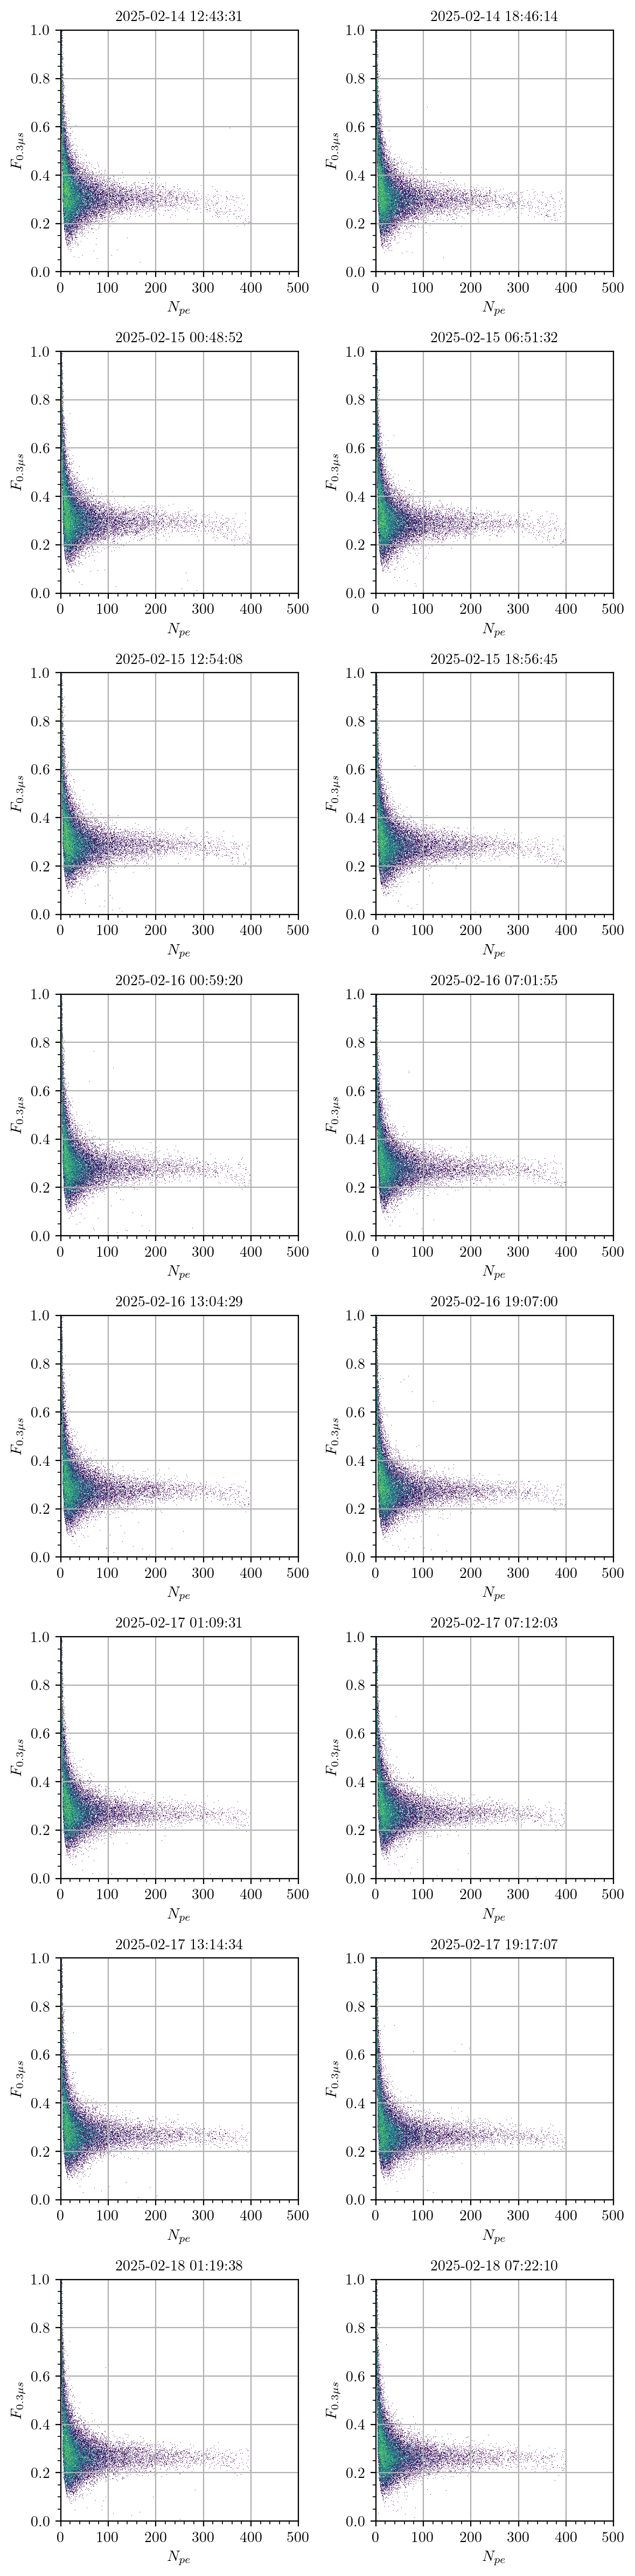

In [34]:
nrows = 8
ncols = len(date_time)//nrows
fig, axs = plt.subplots(nrows, ncols, sharex=False, sharey=False)

fig.set_size_inches(3*ncols, 3*nrows)

for i, dt in enumerate(date_time):
    axs[i//ncols][i%ncols].pcolormesh(
        pe_fp[dt]['xbins'],
        pe_fp[dt]['ybins'],
        np.log10(pe_fp[dt]['counts'])
    )
    axs[i//ncols][i%ncols].minorticks_on()
    axs[i//ncols][i%ncols].grid()
    axs[i//ncols][i%ncols].set_title(f'{dt}')
    axs[i//ncols][i%ncols].set_xlim(0, 500)
    axs[i//ncols][i%ncols].set_ylim(0, 1)
    axs[i//ncols][i%ncols].set_xlabel(r'$N_{pe}$')
    axs[i//ncols][i%ncols].set_ylabel(r'$F_{0.3\mu s}$')
    
# Adjust layout to prevent overlap
fig.tight_layout()

## Laser calibrated single PE shape

In [66]:
# data folder
path = "/scratch/gpfs/as111/results/2023-12-13"
data_spe = {}
channels = np.arange(8)
volt = 98
for ch in channels:
    data_spe[ch] = {'n_spe_wfs':0, 'avg_spe_wf':np.zeros(0), 'time':np.zeros(0)}
    files = glob(f"{path}/*volt_{volt}*laser_waveform_liq5.h5")
    print(files)
    for f in files:
        df = pd.read_hdf(f, key=f'{volt}/{ch}')
        data_spe[ch]['n_spe_wfs'] += np.array(df['n_spe_wfs'])[0]
        if data_spe[ch]['time'].shape[0]==0:
            data_spe[ch]['time'] = np.array(df['time'])
        if np.array(df['n_spe_wfs'])[0]>0:
            if data_spe[ch]['avg_spe_wf'].shape[0]==0:
                data_spe[ch]['avg_spe_wf'] = np.array(df['avg_spe_wf'])*np.array(df['n_spe_wfs'])[0]
            else:
                data_spe[ch]['avg_spe_wf'] += np.array(df['avg_spe_wf'])*np.array(df['n_spe_wfs'])[0]
    df = None
    if data_spe[ch]['n_spe_wfs']>0:
        data_spe[ch]['avg_spe_wf'] /= data_spe[ch]['n_spe_wfs']
    # extend laser waveform from 4000 samp to 5000 samp
    # data_spe[ch]['time'] = np.concatenate([data_spe[ch]['time'],np.arange(4000,5000,1)*0.004])
    # data_spe[ch]['avg_spe_wf'] = np.concatenate([data_spe[ch]['avg_spe_wf'],np.zeros(1000)])
    # trim laser waveform from 4000 samp to 2500 samp
    data_spe[ch]['time'] = data_spe[ch]['time'][:2500]
    data_spe[ch]['avg_spe_wf'] = data_spe[ch]['avg_spe_wf'][:2500]
    

['/scratch/gpfs/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run0_laser_waveform_liq5.h5', '/scratch/gpfs/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run5_laser_waveform_liq5.h5', '/scratch/gpfs/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run3_laser_waveform_liq5.h5', '/scratch/gpfs/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run4_laser_waveform_liq5.h5', '/scratch/gpfs/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run8_laser_waveform_liq5.h5', '/scratch/gpfs/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run2_laser_waveform_liq5.h5', '/scratch/gpfs/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run9_laser_waveform_liq5.h5', '/scratch/gpfs/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run6_laser_waveform_liq5.h5', '/scratch/gpfs/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run1_laser_waveform_liq5.h5', '/scratch/gpfs/as1

ch0 98V 94629 waveforms selected
ch1 98V 130806 waveforms selected
ch2 98V 119307 waveforms selected
ch3 98V 149781 waveforms selected
ch4 98V 156051 waveforms selected
ch5 98V 118384 waveforms selected
ch6 98V 54163 waveforms selected
ch7 98V 53049 waveforms selected


Text(0.07, 0.5, 'Amplitude (ADC Unit)')

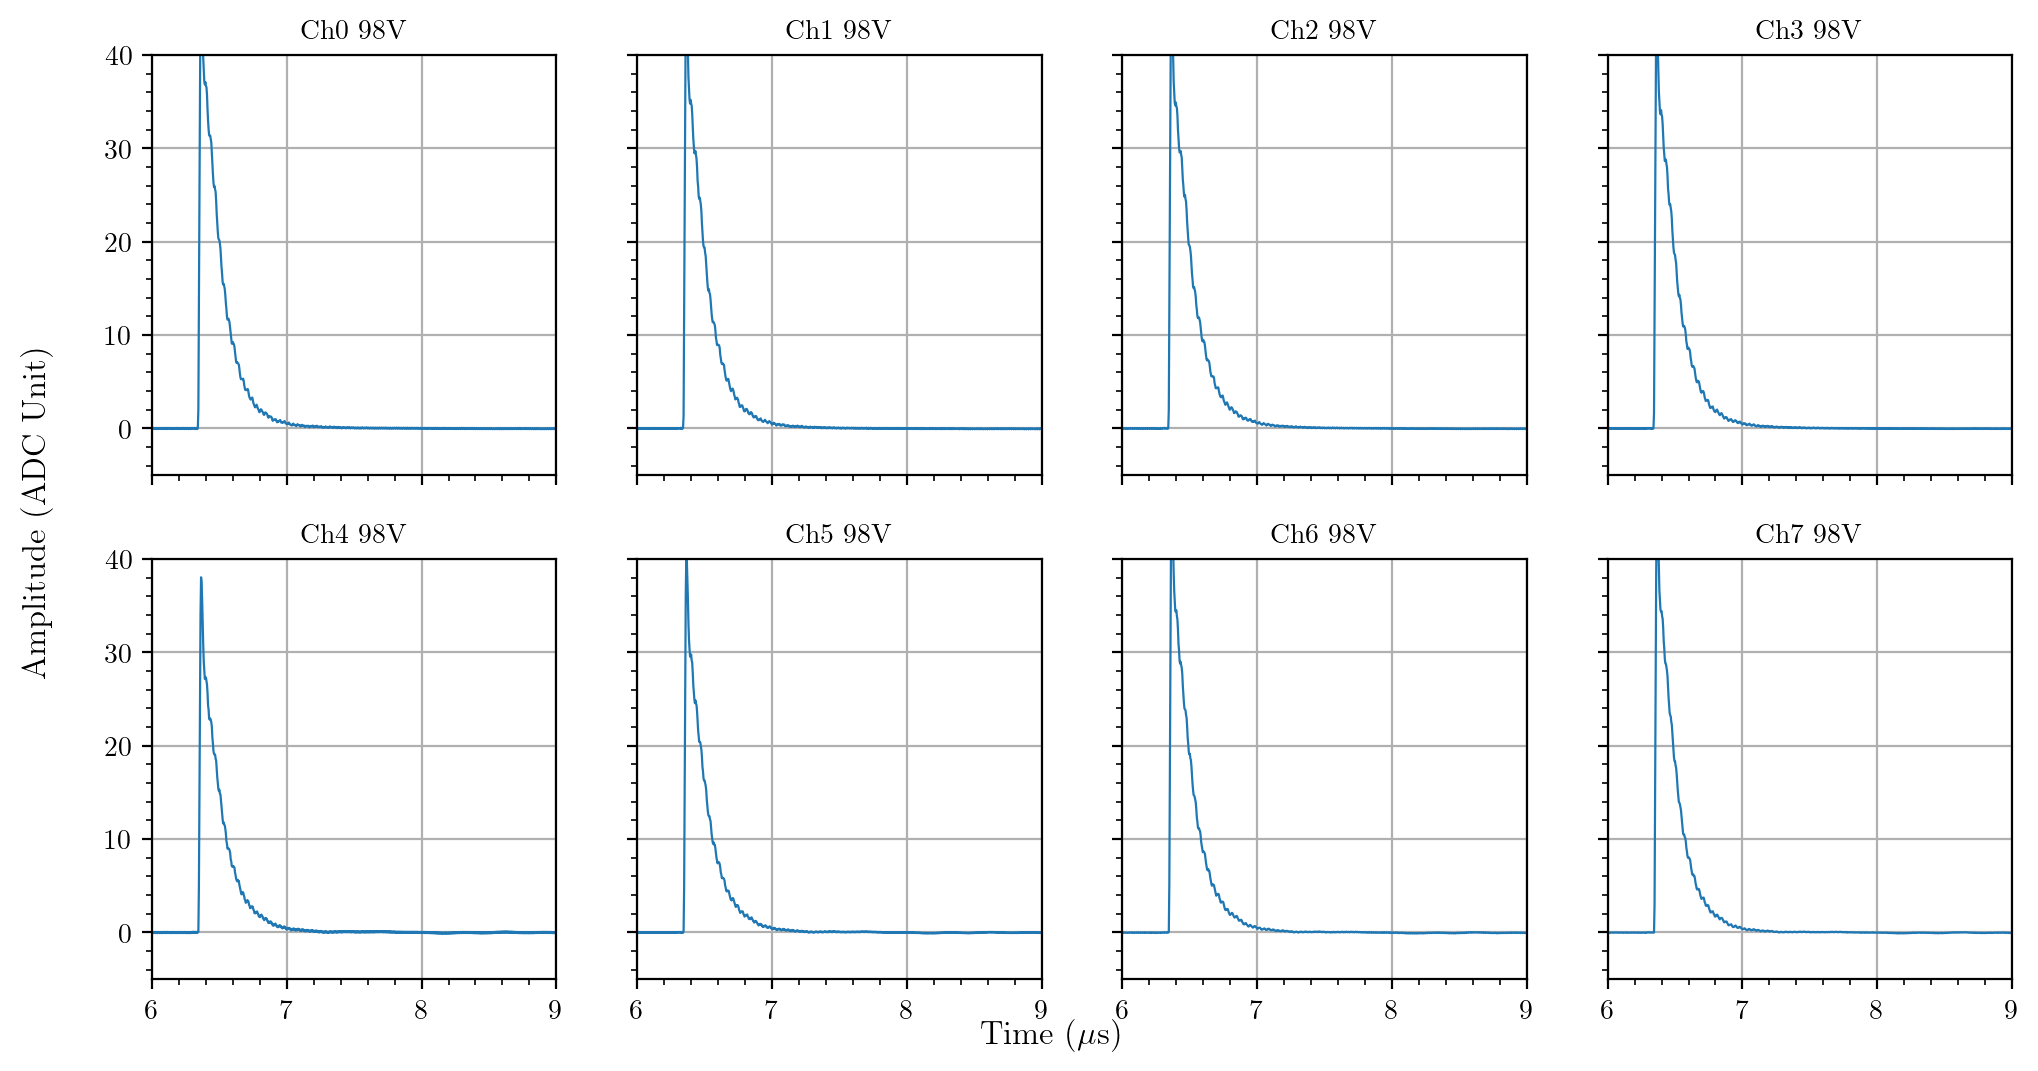

In [67]:
# Make plots for all datasets
# SPE average waveform
fig, axs = plt.subplots(2, 4, sharex=True, sharey=True)
fig.set_size_inches(12, 6)
for j, ch in enumerate(channels):
    if data_spe[ch]['n_spe_wfs']>0:
        print(f'ch{ch} {volt}V {data_spe[ch]["n_spe_wfs"]:.0f} waveforms selected')
        axs[j//4, j%4].plot(
            data_spe[ch]['time'],
            data_spe[ch]['avg_spe_wf'],linewidth=0.8)
    axs[j//4, j%4].set_xlim(6, 9)
    axs[j//4, j%4].set_ylim(-5, 40)
    # axs[j//4, j%4].set_yscale('log')
    axs[j//4, j%4].minorticks_on()
    axs[j//4, j%4].grid()
    axs[j//4, j%4].set_title(f'Ch{ch} {volt}V')
fig.supxlabel(r'Time ($\mu$s)', y=0.05)
fig.supylabel(r'Amplitude (ADC Unit)', x=0.07)

## FFT

Text(0.07, 0.5, 'FFT Abs. Amplitude (ADC Unit)')

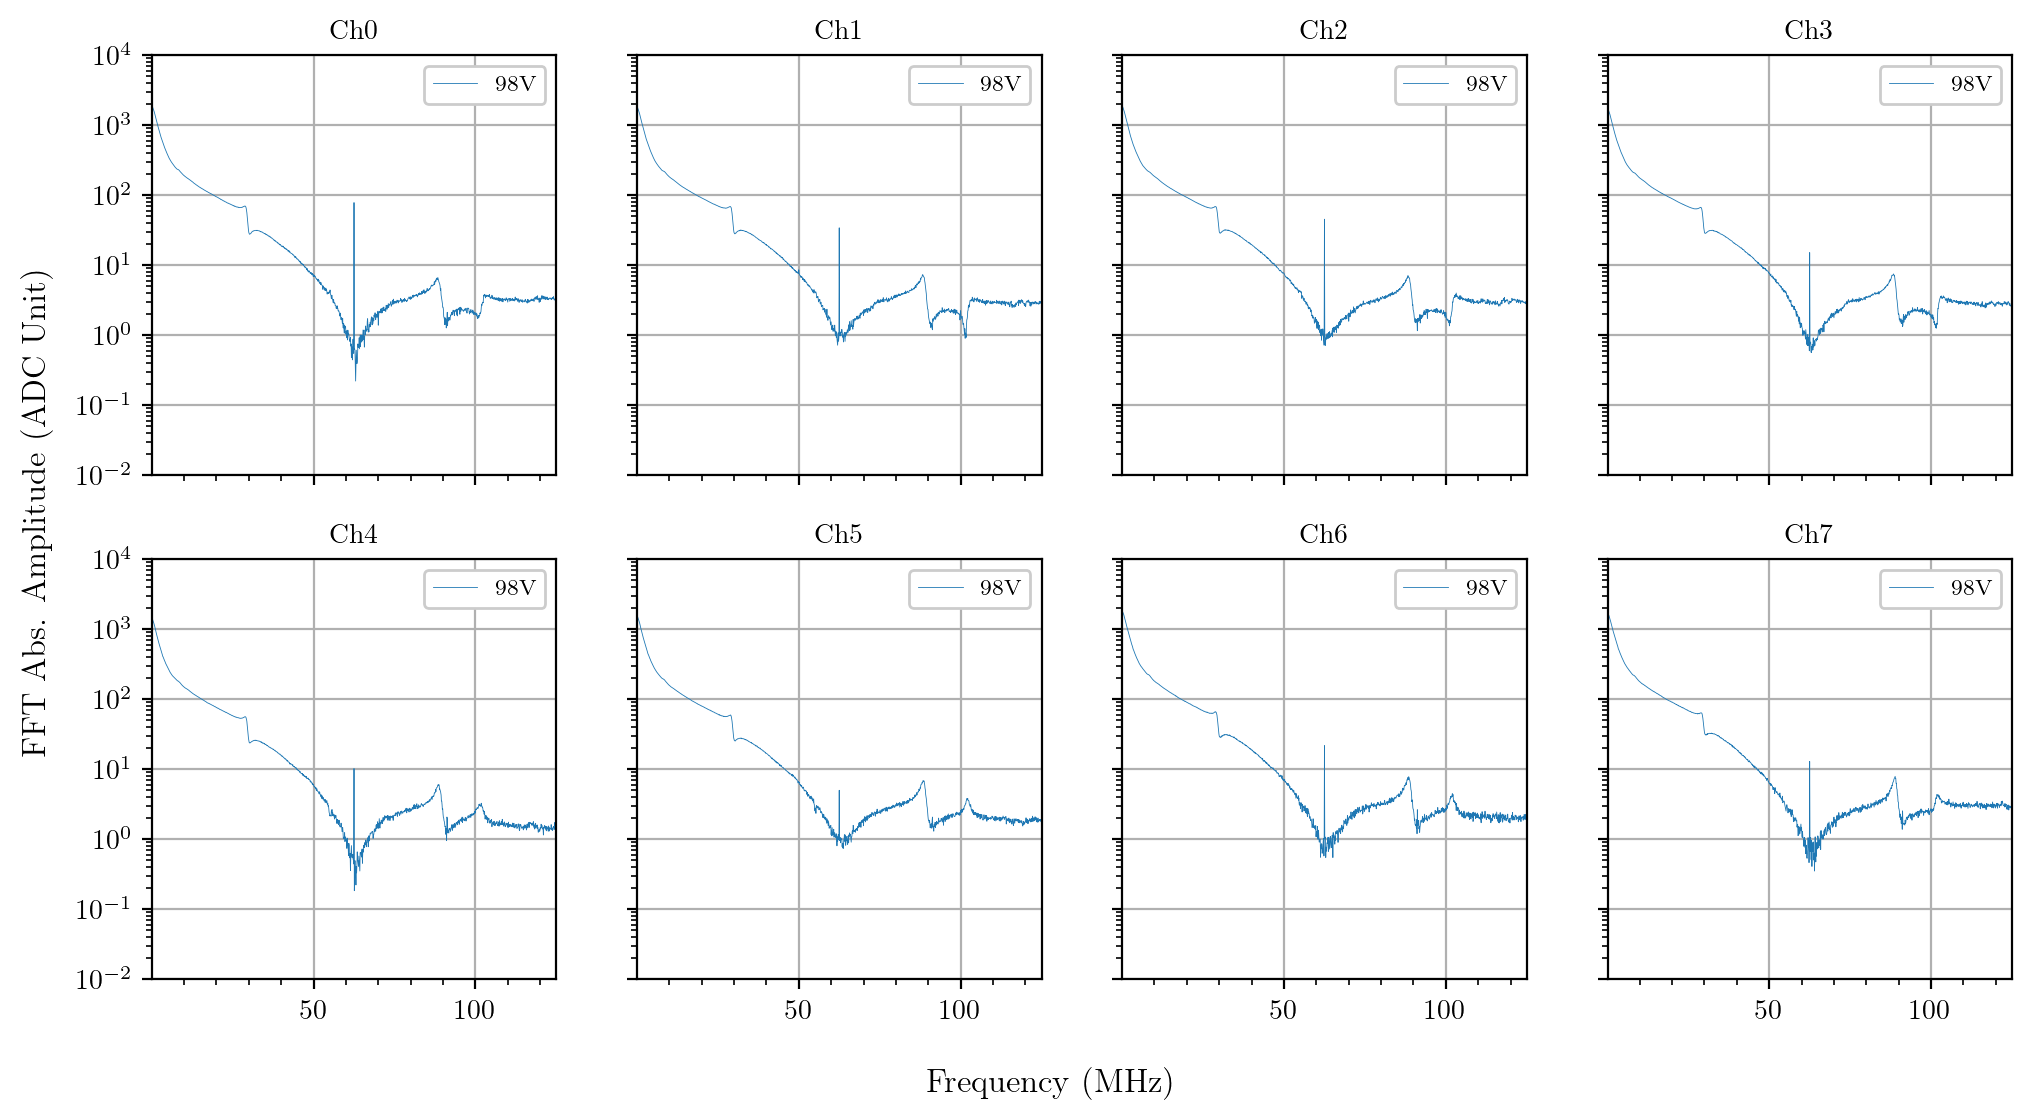

In [68]:
# Make plots for all datasets
# SPE average waveform
fig, axs = plt.subplots(2, 4, sharex=True, sharey=True)
fig.set_size_inches(12, 6)
for j, ch in enumerate(channels):
    data_spe[ch]['fft_spe_wf'] = fft(data_spe[ch]['avg_spe_wf'])
    dt = data_spe[ch]['time'][1]-data_spe[ch]['time'][0]
    t_total = dt+data_spe[ch]['time'][-1]
    n_over_2 = int(data_spe[ch]['time'].shape[0]/2)
    data_spe[ch]['frequency'] = data_spe[ch]['time']/dt/t_total
    axs[j//4, j%4].plot(
        data_spe[ch]['frequency'][:n_over_2],
        abs(data_spe[ch]['fft_spe_wf'][:n_over_2]),
        label=f'{volt}V', linewidth=0.3)
    axs[j//4, j%4].legend(loc='upper right')
    axs[j//4, j%4].set_xlim(data_spe[ch]['frequency'][1], data_spe[ch]['frequency'][n_over_2])
    axs[j//4, j%4].set_ylim(1e-2, 1e4)
    axs[j//4, j%4].set_yscale('log')
    axs[j//4, j%4].minorticks_on()
    axs[j//4, j%4].grid()
    axs[j//4, j%4].set_title(f'Ch{ch}')
fig.supxlabel(r'Frequency (MHz)', y=0.01)
fig.supylabel(r'FFT Abs. Amplitude (ADC Unit)', x=0.07)

## # Fit: exponential pulses with time jitter

Scintillation pulse (one component):
$$h(t,t') = A e^{-\frac{t-t'}{\tau}} \Theta(t-t')$$
Time jitter:
$$g(t') = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{(t'-t_0)^2}{2\sigma^2}}$$
Average waveform:
$$
f(t,t') = \int g(t') h(t,t') \, dt'
= \frac{A}{\sigma\sqrt{2\pi}} \int_{-\infty}^{t} e^{-\frac{(t'-t_0)^2}{2\sigma^2}-\frac{t-t'}{\tau}} \, dt'$$

$$ = \frac{A}{\sigma\sqrt{2\pi}} \int_{-\infty}^{t} e^{-\frac{1}{2\sigma^2}[t^{'2} - 2t'(t_0 + \sigma^2/\tau) + t_0^2 + 2\sigma^2 t_0/\tau + \sigma^4 /\tau^2 + 2\sigma^2 (t-t_0)/\tau - \sigma^4/\tau^2]} \, dt'
$$

$$
= \frac{Ae^{\frac{\sigma^2}{2\tau^2}}}{\sigma\sqrt{2\pi}} e^{-\frac{t-t_0}{\tau}} \int_{-\infty}^{t} e^{-\frac{1}{2\sigma^2}[t'-(t_0 + \sigma^2/\tau)]^2} \, dt'
$$

$$
= \frac{Ae^{\frac{\sigma^2}{2\tau^2}}}{\sqrt{\pi}} e^{-\frac{t-t_0}{\tau}} \int_{-\infty}^{t/\sigma\sqrt{2}} e^{-[x'-\frac{t_0 + \sigma^2/\tau}{\sigma\sqrt{2}}]^2} \, dx'
$$

$$
= \frac{Ae^{\frac{\sigma^2}{2\tau^2}}}{2} e^{-\frac{t-t_0}{\tau}} \left[1 + erf\left(\frac{t-t_0-\sigma^2/\tau}{\sigma\sqrt{2}}\right)\right]
$$
We include two scintillation pulse components with distinct $\tau$.

In [69]:
def template(t, a_1, tau_1, sigma, t0):
        return func.pulse_jitter(t, a_1, tau_1, sigma, t0)

In [70]:
# Fit SPE average waveform
for j, ch in enumerate(channels):
    pretrg = 5 #us
    err = np.std(data_spe[ch]['avg_spe_wf'][data_spe[ch]['time']<pretrg])
    fit_range = [6.2,7.5] #us
    range_arr = (data_spe[ch]['time']<fit_range[1])&(data_spe[ch]['time']>fit_range[0])
    # print(pos,ch,volt)
    # print(data_spe[pos][ch][volt]['time'][range_arr])
    # print(data_spe[pos][ch][volt]['avg_spe_wf'][range_arr])
    popt,pcov = curve_fit(
        template,
        data_spe[ch]['time'][range_arr], 
        data_spe[ch]['avg_spe_wf'][range_arr], 
        p0=[20, 0.15, 0.005, 6.35], sigma=err*np.ones(np.sum(range_arr)), maxfev=100000)
    data_spe[ch]['pars'] = popt
    data_spe[ch]['cov'] = pcov
    print(popt)

[5.18882743e+01 1.45652187e-01 5.24822755e-03 6.35197886e+00]
[4.89816504e+01 1.47975857e-01 5.04287800e-03 6.35189741e+00]
[4.85542993e+01 1.51878563e-01 4.94892909e-03 6.35147961e+00]
[4.73832736e+01 1.47520794e-01 5.00433097e-03 6.35165182e+00]
[3.85683043e+01 1.47689731e-01 4.80248889e-03 6.35362990e+00]
[4.15716795e+01 1.46750985e-01 4.89224968e-03 6.35379402e+00]
[4.82421692e+01 1.46867383e-01 5.04640953e-03 6.35411272e+00]
[4.85213927e+01 1.40289918e-01 5.07136632e-03 6.35516146e+00]


# Triplet lifetime
Here the average waveforms are deconvolved channel-by-channel using their respective SPE pulse shapes.
The deconvolved waveform is given by
$$f_{deconv}(t) = \mathcal{F}^{-1}\left(\frac{\mathcal{F}(f_{original}(t))}{\mathcal{F}(f_{SiPM}(t))}\right)$$
Note that the SiPM pulse shape has to be shifted such that the trigger for it is at $t=0$.<br>

The average waveforms are selected from the events with $0.1<F_{\rm prompt}<0.5$ and $20<N_{\rm PE}<200$ ($100<N_{\rm PE}<1000$) for the top (bottom), corresponding to an energy range of $100$ keV $\lesssim E \lesssim 1000$ keV

In [71]:
def downsample(input_t,input_wf,nsub):
    ntot = int(input_t.shape[0]//nsub * nsub)
    new_t, new_wf = np.zeros(ntot//nsub), np.zeros(ntot//nsub)
    for i in range(nsub):
        new_t += input_t[i:ntot:nsub]
        new_wf += input_wf[i:ntot:nsub]
    new_t /= nsub
    new_wf /= nsub
    return new_t, new_wf

In [72]:
S_PER_HR = 3600
dt_getter = datetime(2025,2,11,20,42,0)
print('The getter was turned on at', dt_getter)

The getter was turned on at 2025-02-11 20:42:00


In [73]:
# Pure LAr
path = "/scratch/gpfs/as111/results/"
dates = ['2025-02-14']
files = []
for d in dates:
    files.extend(glob(f"{path}{d}/*cond_monitor*scintillation_waveform_liq8.h5"))
for i,f in enumerate(files):
    files[i] = [files[i]]
print(files)
print(len(files))

[['/scratch/gpfs/as111/results/2025-02-14/2025-02-14_volt_98_light_scintillation_cond_monitor_source_na22_run5_scintillation_waveform_liq8.h5'], ['/scratch/gpfs/as111/results/2025-02-14/2025-02-14_volt_98_light_scintillation_cond_monitor_source_na22_run9_scintillation_waveform_liq8.h5'], ['/scratch/gpfs/as111/results/2025-02-14/2025-02-14_volt_98_light_scintillation_cond_monitor_source_na22_run8_scintillation_waveform_liq8.h5'], ['/scratch/gpfs/as111/results/2025-02-14/2025-02-14_volt_98_light_scintillation_cond_monitor_source_na22_run3_scintillation_waveform_liq8.h5'], ['/scratch/gpfs/as111/results/2025-02-14/2025-02-14_volt_98_light_scintillation_cond_monitor_source_na22_run4_scintillation_waveform_liq8.h5'], ['/scratch/gpfs/as111/results/2025-02-14/2025-02-14_volt_98_light_scintillation_cond_monitor_source_na22_run11_scintillation_waveform_liq8.h5'], ['/scratch/gpfs/as111/results/2025-02-14/2025-02-14_volt_98_light_scintillation_cond_monitor_source_na22_run13_scintillation_waveform_

In [74]:
# data folder
data_scint = {}
date_time = {}
channels = [1,2,4,7]
ch_old = [0,5,6,3,4,1,2,7] # map to channels in liq5 calibration data
volt = 98
for i,fs in enumerate(files):
    data_scint[i] = {}
    for j,f in enumerate(fs):
        df = pd.read_hdf(f, key=f'{volt}/-1')
        if j==0:
            date_time[i] = datetime(*np.array(df['start_datetime'][:6]).astype(int))
        for ch in channels:
            if j==0:
                data_scint[i][ch] = {'n_scint_wfs':0, 'avg_scint_wf':np.zeros(0), 'time':np.zeros(0)}
            df = pd.read_hdf(f, key=f'{volt}/{ch}')
            data_scint[i][ch]['n_scint_wfs'] += np.array(df['n_scint_wfs'])[0]
            if data_scint[i][ch]['time'].shape[0]==0:
                data_scint[i][ch]['time'] = np.array(df['time'].dropna())
            if data_scint[i][ch]['avg_scint_wf'].shape[0]==0:
                data_scint[i][ch]['avg_scint_wf'] = np.array(df['avg_scint_wf'].dropna())*np.array(df['n_scint_wfs'])[0]
            else:
                data_scint[i][ch]['avg_scint_wf'] += np.array(df['avg_scint_wf'].dropna())*np.array(df['n_scint_wfs'])[0]
            df = None
            data_scint[i][ch]['avg_scint_wf'] /= data_scint[i][ch]['n_scint_wfs']
# sort according to date time
args = np.array(list(date_time.values())).argsort()
files = [files[i] for i in args]
data_scint = [data_scint[i] for i in args]
date_time = [date_time[i] for i in args]
hr_from_getter = [(dt-dt_getter).total_seconds()/S_PER_HR for dt in date_time]

2025-02-14 12:43:31 ch1 25223 waveforms selected
2025-02-14 18:46:14 ch1 25315 waveforms selected
2025-02-15 00:48:52 ch1 25779 waveforms selected
2025-02-15 06:51:32 ch1 25621 waveforms selected
2025-02-15 12:54:08 ch1 25984 waveforms selected
2025-02-15 18:56:45 ch1 25743 waveforms selected
2025-02-16 00:59:20 ch1 25885 waveforms selected
2025-02-16 07:01:55 ch1 26161 waveforms selected
2025-02-16 13:04:29 ch1 26197 waveforms selected
2025-02-16 19:07:00 ch1 26034 waveforms selected
2025-02-17 01:09:31 ch1 26152 waveforms selected
2025-02-17 07:12:03 ch1 26270 waveforms selected
2025-02-17 13:14:34 ch1 26141 waveforms selected
2025-02-17 19:17:07 ch1 26271 waveforms selected
2025-02-18 01:19:38 ch1 26601 waveforms selected
2025-02-18 07:22:10 ch1 26601 waveforms selected
2025-02-14 12:43:31 ch2 25223 waveforms selected
2025-02-14 18:46:14 ch2 25315 waveforms selected
2025-02-15 00:48:52 ch2 25779 waveforms selected
2025-02-15 06:51:32 ch2 25621 waveforms selected
2025-02-15 12:54:08 

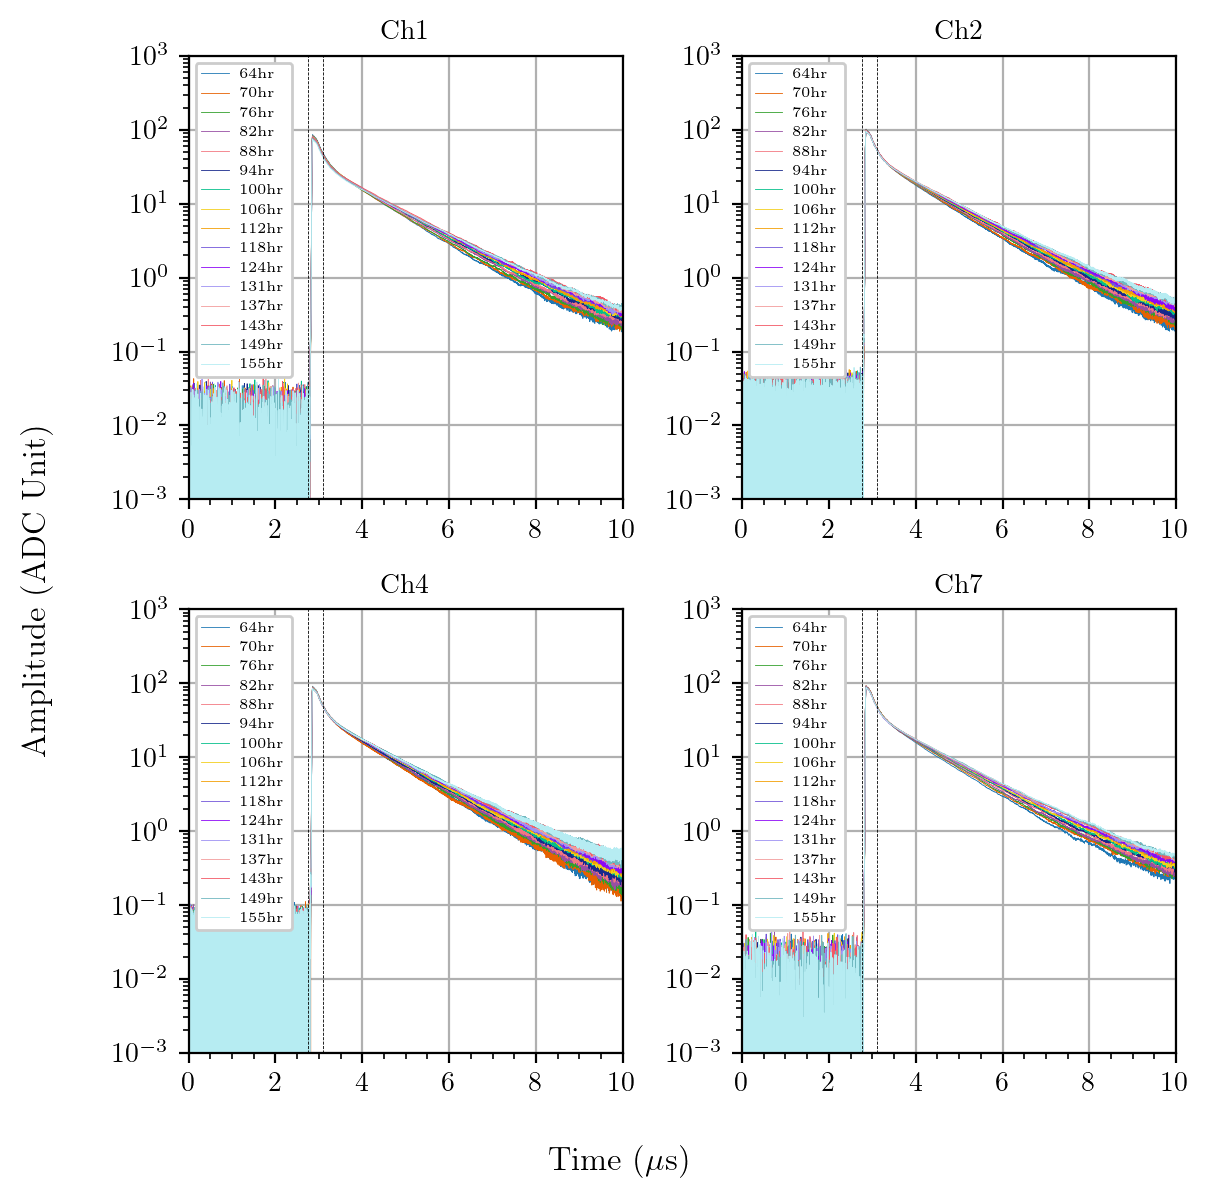

In [75]:
# Make plots for all datasets
# Average LAr scintillation waveform
t_trig = 2.8
ylims = (1e-3,1e3)
fig, axs = plt.subplots(2, 2, sharex=False, sharey=False)
fig.set_size_inches(6, 6)
for j, ch in enumerate(channels):
    for k, f in enumerate(files):
        print(f'{date_time[k]} ch{ch} {data_scint[k][ch]["n_scint_wfs"]:.0f} waveforms selected')
        axs[j//2, j%2].plot(
            data_scint[k][ch]['time'],
            data_scint[k][ch]['avg_scint_wf'],
            label=f'{hr_from_getter[k]:.0f}hr', color=f'C{k}', linewidth=0.3)
    axs[j//2, j%2].legend(loc='upper left',fontsize=5)
    axs[j//2, j%2].set_xlim(0, 10)
    axs[j//2, j%2].set_ylim(*ylims)
    axs[j//2, j%2].set_yscale('log')
    axs[j//2, j%2].minorticks_on()
    axs[j//2, j%2].grid()
    axs[j//2, j%2].set_title(f'Ch{ch}')
    axs[j//2, j%2].plot([t_trig-10*0.004]*2, ylims, 'k--',linewidth=0.3)
    axs[j//2, j%2].plot([t_trig+0.3]*2, ylims, 'k--',linewidth=0.3)
fig.supxlabel(r'Time ($\mu$s)', y=0.01)
fig.supylabel(r'Amplitude (ADC Unit)', x=0.00)
fig.tight_layout()

## Deconvolution

In [76]:
# Deconvolution channel by channel
for i, f in enumerate(files):
    for j, ch in enumerate(channels):
        if data_scint[i][ch]['n_scint_wfs']>0 and data_spe[ch_old[ch]]['n_spe_wfs']>0:
            dt = data_spe[ch_old[ch]]['time'][1]-data_spe[ch_old[ch]]['time'][0]
            shift = np.array([np.exp(complex(0,-2*np.pi*freq*dt*int(data_spe[ch_old[ch]]['pars'][3]/dt))) for freq in data_spe[ch_old[ch]]['frequency']])
            data_scint[i][ch]['deconv'] = ifft(fft(data_scint[i][ch]['avg_scint_wf'])/data_spe[ch_old[ch]]['fft_spe_wf']*shift).real

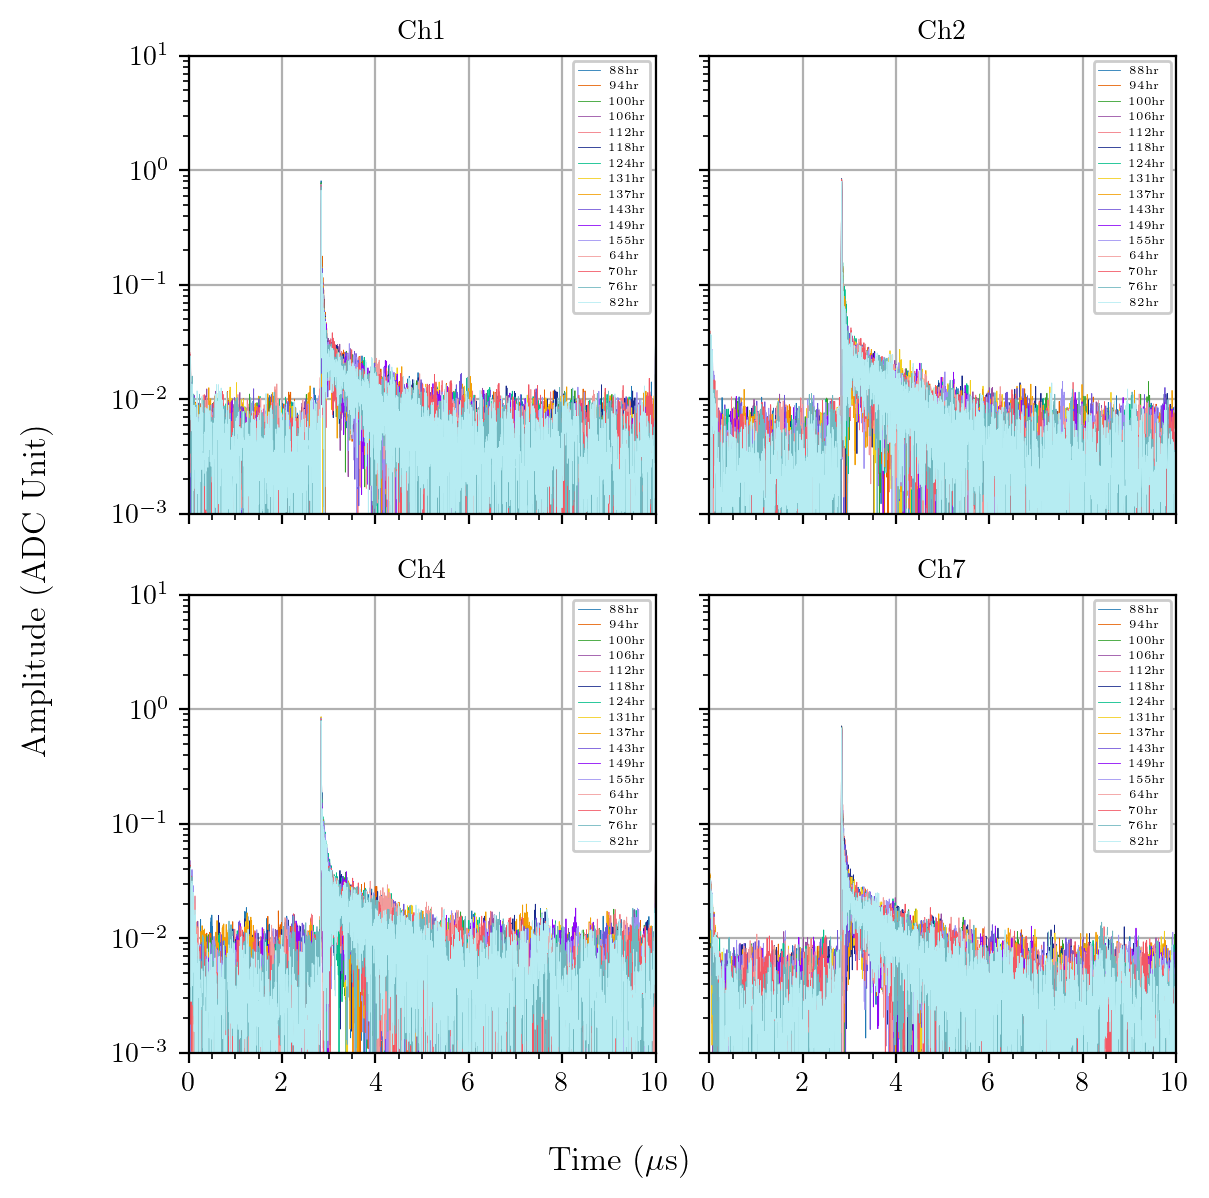

In [80]:
# Make plots for all datasets
# Deconvolved scintillation waveform
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
fig.set_size_inches(6, 6)
for j, ch in enumerate(channels):
    for k, f in enumerate(files):
        if data_scint[k][ch]['n_scint_wfs']>0 and data_spe[ch]['n_spe_wfs']>0:
            axs[j//2, j%2].plot(
                data_scint[k][ch]['time'],
                abs(data_scint[k][ch]['deconv']),
                label=f'{hr_from_getter[-12+k]:.0f}hr', color=f'C{k}', linewidth=0.3)
    axs[j//2, j%2].legend(loc='upper right', fontsize=4)
    axs[j//2, j%2].set_xlim(0, 10)
    axs[j//2, j%2].set_ylim(1e-3, 1e1)
    axs[j//2, j%2].set_yscale('log')
    axs[j//2, j%2].minorticks_on()
    axs[j//2, j%2].grid()
    axs[j//2, j%2].set_title(f'Ch{ch}')
fig.supxlabel(r'Time ($\mu$s)', y=0.01)
fig.supylabel(r'Amplitude (ADC Unit)', x=0.0)
plt.tight_layout()

## Summation + Downsampling

In [92]:
# summation
for i,f in enumerate(files):
    data_scint[i][-1] = {'time': data_scint[i][channels[0]]['time'], 'sum_wf': np.zeros(data_scint[i][channels[0]]['time'].shape[0])}
    data_scint[i][-1]['sum_wf'] += data_scint[i][ch]['deconv']

In [93]:
# subsampling
nsub = 4
for i,f in enumerate(files):
    data_scint[i][-1]['time_sub'], data_scint[i][-1]['sum_wf_sub'] = downsample(data_scint[i][-1]['time'],data_scint[i][-1]['sum_wf'],nsub)

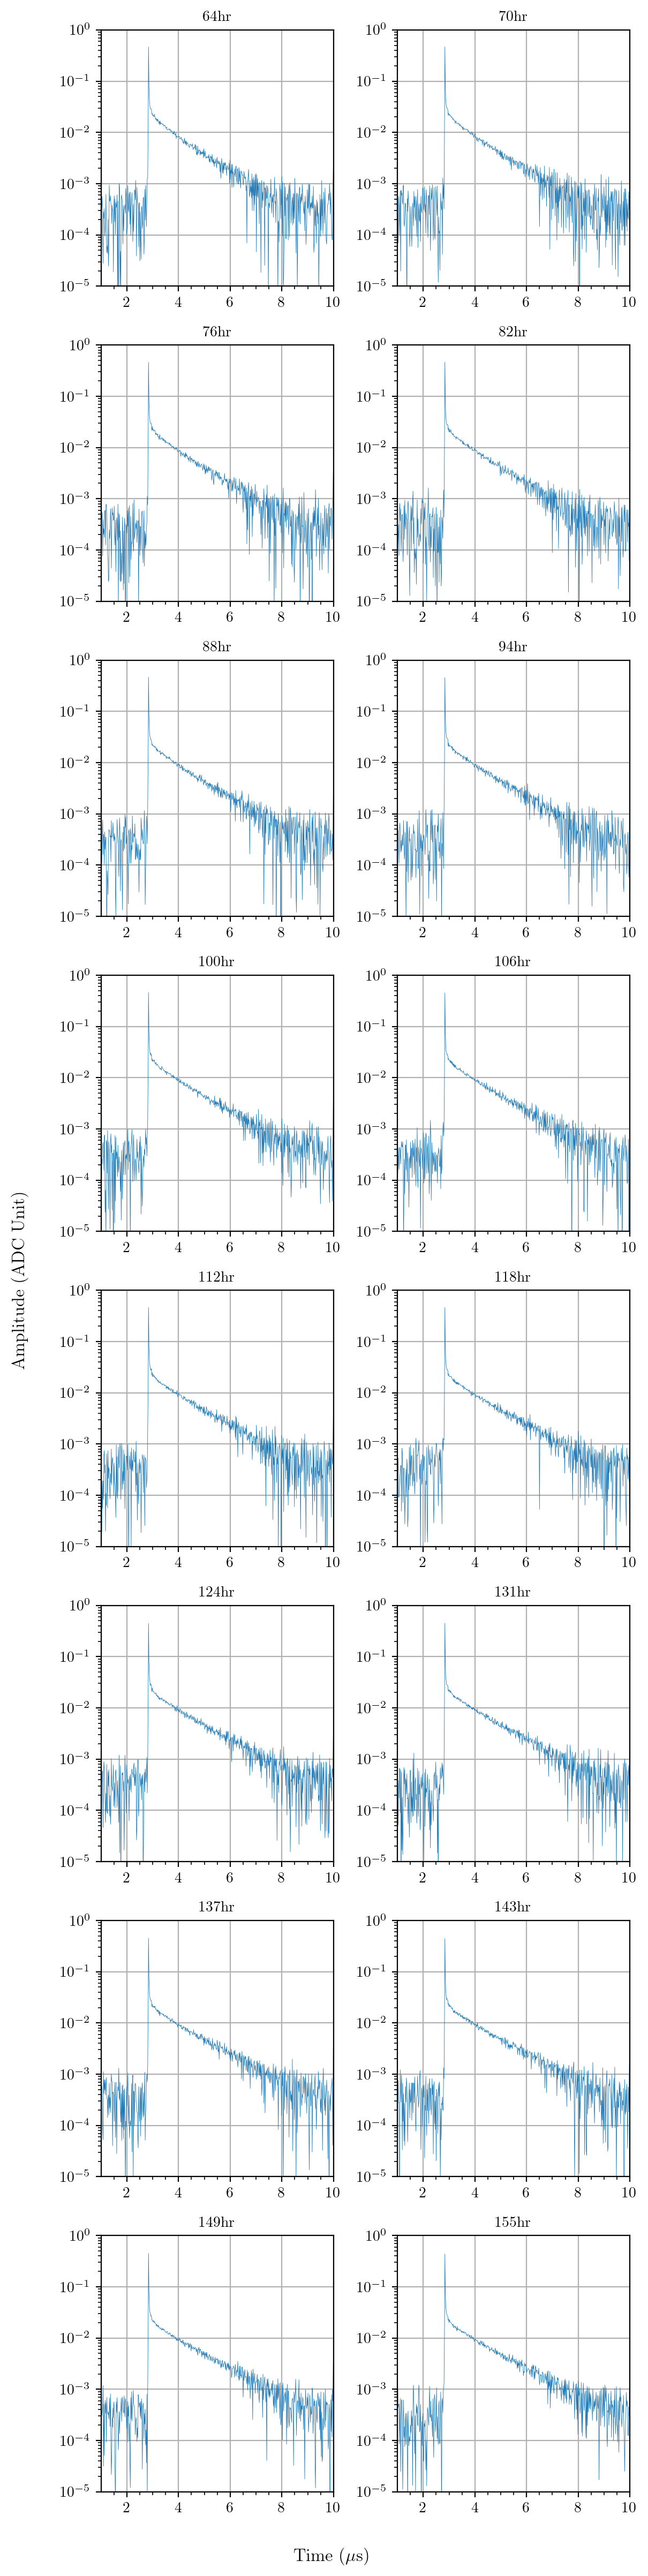

In [102]:
# Make plots for all datasets
# Summed scintillation waveform
ncols = 2
nrows = len(files)//ncols
fig, axs = plt.subplots(nrows, ncols, sharex=False, sharey=False)
fig.set_size_inches(3*ncols, 3*nrows)
for i, f in enumerate(files):
    axs[i//2, i%2].plot(
		data_scint[i][-1]['time_sub'],
		abs(data_scint[i][-1]['sum_wf_sub']),linewidth=0.3)
    axs[i//2, i%2].set_xlim(1, 10)
    axs[i//2, i%2].set_ylim(1e-5, 1e0)
    axs[i//2, i%2].set_yscale('log')
    axs[i//2, i%2].minorticks_on()
    axs[i//2, i%2].grid()
    axs[i//2, i%2].set_title(f'{hr_from_getter[i]:.0f}hr')
fig.supxlabel(r'Time ($\mu$s)', y=0.0)
fig.supylabel(r'Amplitude (ADC Unit)', x=0.0)
plt.tight_layout()

## Fitting

In [95]:
t_trig = 2.8
def template3(t,a,tau):
    return a/tau*0.004*np.exp(-(t-t_trig)/tau)

In [96]:
# Fit SPE average waveform
data_sub = {}
for i,f in enumerate(files):
    if data_scint[i][-1]['sum_wf'].shape[0]>0:
        pretrg = 2.5 #us
        # simple exponential fit to windowless
        fit_range = [3.1,8] #us
        err = np.std(data_scint[i][-1]['sum_wf_sub'][data_scint[i][-1]['time_sub']<pretrg])
        
        # simple exponential fit to windowless
        range_arr = (data_scint[i][-1]['time_sub']<fit_range[1]) & (data_scint[i][-1]['time_sub']>fit_range[0])
        popt,pcov = curve_fit(
            template3,
            data_scint[i][-1]['time_sub'][range_arr], 
            data_scint[i][-1]['sum_wf_sub'][range_arr], 
            p0=[100,1], sigma=err*np.ones(np.sum(range_arr)), maxfev=100000)
                
        data_scint[i][-1]['pars'] = popt
        data_scint[i][-1]['cov'] = pcov
        data_scint[i][-1]['pars_err'] = np.array([func.error_distance(df=2, sigma=1)*pcov[j,j]**0.5 for j in range(len(popt))])
        data_scint[i][-1]['fit_range'] = fit_range
        
        # simple exponential fit to windowless
        print(f'{date_time[i]} A={popt[0]:.2f}+/-{data_scint[i][-1]["pars_err"][0]:.2f} tau={popt[1]:.3f}+/-{data_scint[i][-1]["pars_err"][1]:.3f}us')
        

2025-02-14 12:43:31 A=6.88+/-0.06 tau=1.192+/-0.017us
2025-02-14 18:46:14 A=7.10+/-0.06 tau=1.226+/-0.018us
2025-02-15 00:48:52 A=7.21+/-0.06 tau=1.262+/-0.019us
2025-02-15 06:51:32 A=7.26+/-0.05 tau=1.289+/-0.017us
2025-02-15 12:54:08 A=7.48+/-0.06 tau=1.292+/-0.018us
2025-02-15 18:56:45 A=7.57+/-0.06 tau=1.325+/-0.020us
2025-02-16 00:59:20 A=7.54+/-0.06 tau=1.342+/-0.018us
2025-02-16 07:01:55 A=7.64+/-0.06 tau=1.364+/-0.020us
2025-02-16 13:04:29 A=7.77+/-0.07 tau=1.385+/-0.021us
2025-02-16 19:07:00 A=7.79+/-0.06 tau=1.403+/-0.019us
2025-02-17 01:09:31 A=7.71+/-0.06 tau=1.411+/-0.020us
2025-02-17 07:12:03 A=7.80+/-0.06 tau=1.419+/-0.018us
2025-02-17 13:14:34 A=7.87+/-0.06 tau=1.436+/-0.021us
2025-02-17 19:17:07 A=7.94+/-0.06 tau=1.457+/-0.020us
2025-02-18 01:19:38 A=7.99+/-0.06 tau=1.462+/-0.020us
2025-02-18 07:22:10 A=7.96+/-0.06 tau=1.469+/-0.019us


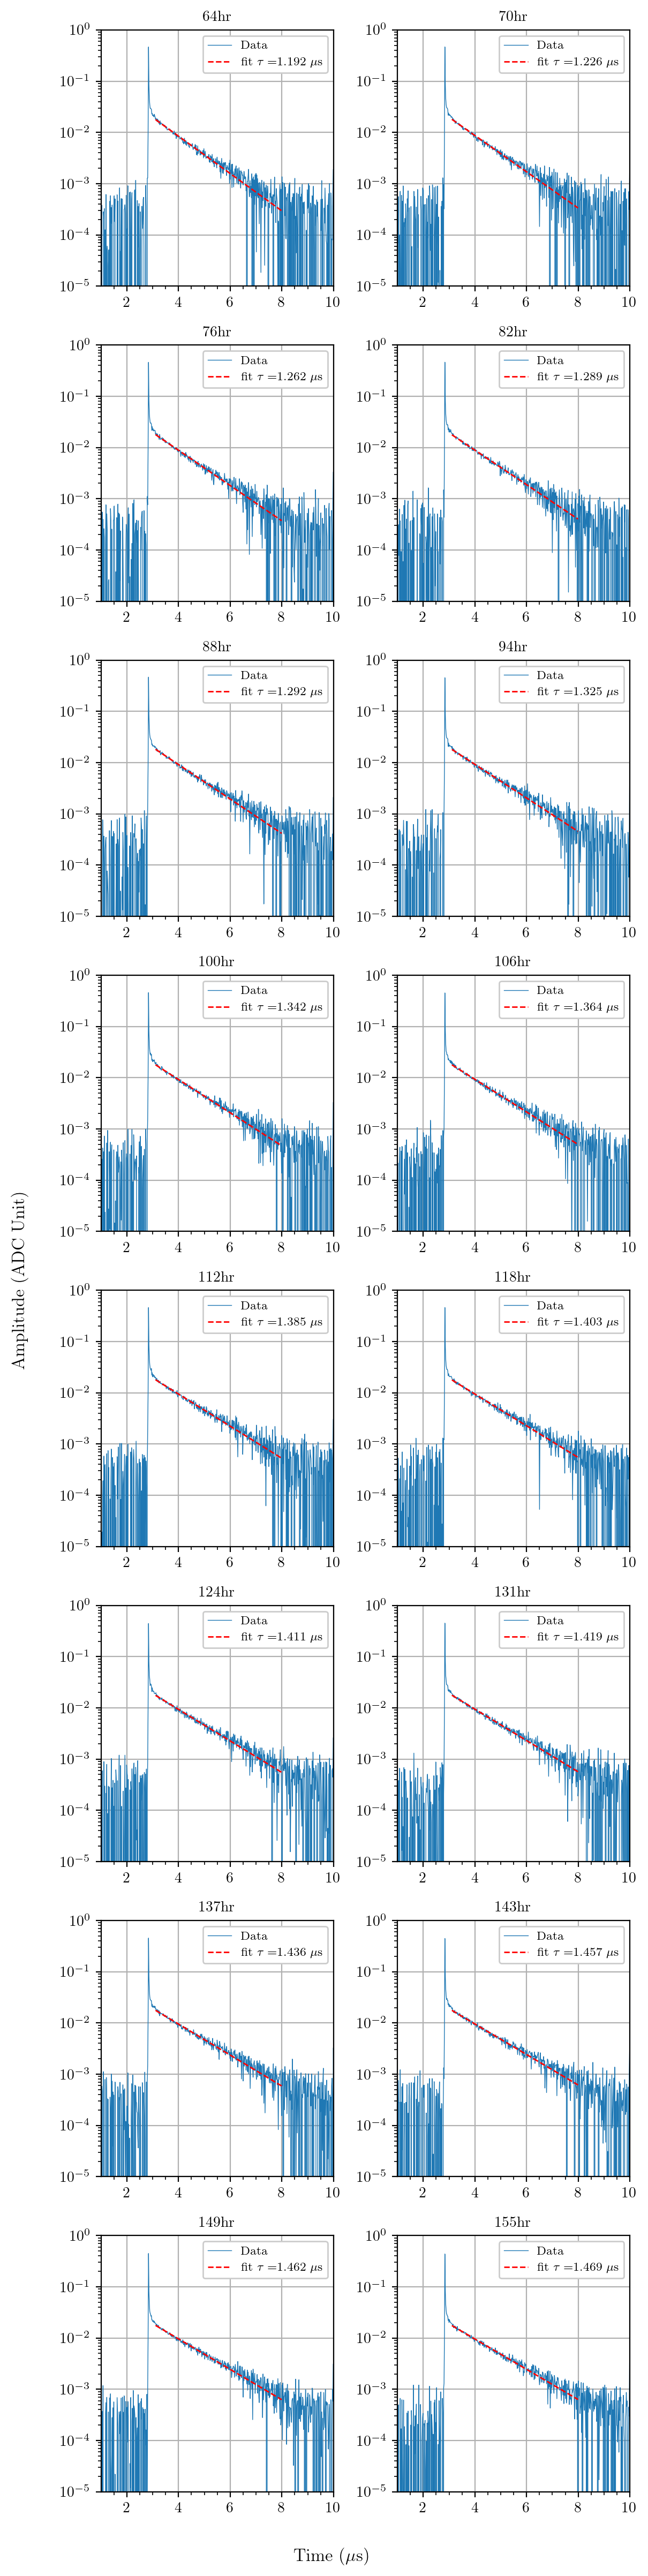

In [103]:
# Make plots for all datasets
ncols = 2
nrows = len(files)//ncols
fig, axs = plt.subplots(nrows, ncols, sharex=False, sharey=False)
fig.set_size_inches(3*ncols, 3*nrows)
for i, f in enumerate(files):
    if data_scint[i][-1]['sum_wf'].shape[0]>0:
        axs[i//2, i%2].plot(
            data_scint[i][-1]['time_sub'],
            data_scint[i][-1]['sum_wf_sub'],
            label='Data', color='C0', linewidth=0.5)
        mask = (data_scint[i][-1]['time_sub']>data_scint[i][-1]['fit_range'][0]) & (data_scint[i][-1]['time_sub']<data_scint[i][-1]['fit_range'][1])
        axs[i//2, i%2].plot(
            data_scint[i][-1]['time_sub'][mask],
            template3(data_scint[i][-1]['time_sub'][mask], *data_scint[i][-1]['pars']),
            label=r'fit $\tau=${:.3f} $\mu $s'.format(data_scint[i][-1]['pars'][1]), color='r', linestyle='--', linewidth=1)
        axs[i//2, i%2].legend(loc='upper right',ncol=1)
        axs[i//2, i%2].set_xlim(1, 10)
        axs[i//2, i%2].set_ylim(1e-5, 1e0)
        axs[i//2, i%2].set_yscale('log')
        axs[i//2, i%2].minorticks_on()
        axs[i//2, i%2].grid()
        axs[i//2, i%2].set_title(f'{hr_from_getter[i]:.0f}hr')
fig.supxlabel(r'Time ($\mu$s)', y=0.0)
fig.supylabel(r'Amplitude (ADC Unit)', x=0.0)
plt.tight_layout()

## Triplet lifetime evolution

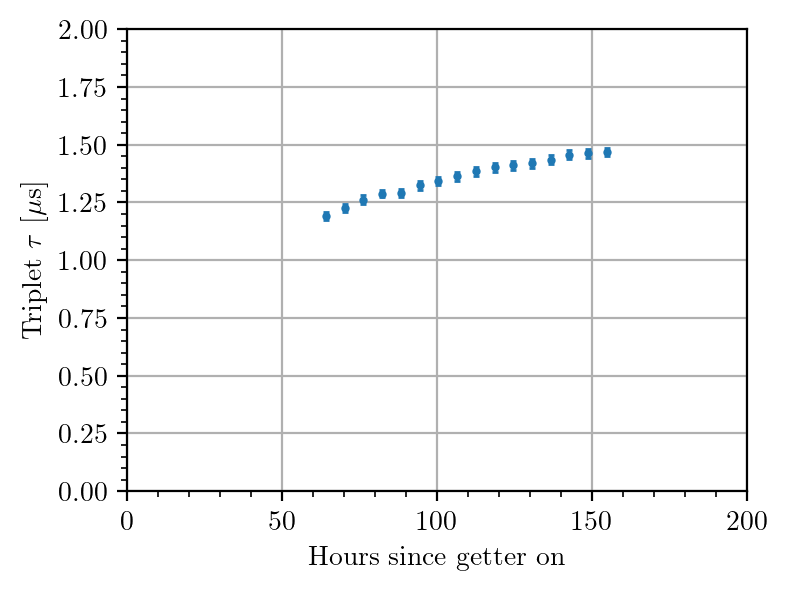

In [106]:
plt.errorbar(
	hr_from_getter,
	[data_scint[j][-1]['pars'][1] for j in range(len(files))],
	yerr=[func.error_distance(df=2, sigma=1)*np.sqrt(data_scint[j][-1]['cov'][1,1]) for j in range(len(files))],
	linestyle='', linewidth=1, fmt='o', markersize=2, capsize=1
)
plt.plot([0]*2,[0,2],'k--',linewidth=0.6)
plt.ylabel(r'Triplet $\tau~\rm [\mu s]$')
plt.ylim(0,2)
plt.minorticks_on()
plt.grid()
plt.xlim(0,200)
plt.xlabel('Hours since getter on')
fig.tight_layout()